In [1]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.1 MB/s eta 0:00:00


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="iyLsqEim9nAoDa24N72g")
project = rf.workspace("industrial-engineer").project("cotton-disease-zrbov")
version = project.version(21)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 115.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Cotton-Disease-21 in yolov11:: 100%|██████████| 23420/23420 [00:06<00:00, 3714.18it/s] 


In [3]:
!nvidia-smi

Sat Sep 13 10:55:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.8/112.6 GB disk)


In [5]:
from ultralytics import YOLO
from IPython.display import Image

In [6]:
dataset.location

'/content/Cotton-Disease-21'

In [8]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.yaml")  # build a new model from YAML
model = YOLO("yolo11n.pt")  # load a pretrained model (recommended for training)
model = YOLO("yolo11n.yaml").load("yolo11n.pt")  # build from YAML and transfer weights

# Train the model
results = model.train(data="/content/Cotton-Disease-21/data.yaml", epochs=50, imgsz=640)

Transferred 499/499 items from pretrained weights
Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Cotton-Disease-21/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

In [1]:
Image('/content/runs/detect/train2/results.png',width=640)

NameError: name 'Image' is not defined

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11m.pt")  # load an official model
model = YOLO("/content/runs/detect/train/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list

100%|██████████| 38.8M/38.8M [00:00<00:00, 48.6MB/s]


Ultralytics 8.3.94 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning /content/Cotton-Disease-16/valid/labels.cache... 432 images, 38 backgrounds, 0 corrupt: 100%|██████████| 432/432 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:09<00:00,  2.79it/s]


                   all        432        402       0.98      0.759      0.846      0.778
Speed: 1.6ms preprocess, 10.2ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/val


array([    0.77833])

In [ ]:
# Predict with the model
results = model("/content/Cotton-Disease-16/test/images/116_jpg.rf.ffa3e1aca066d956b98e792100af6193.jpg")  # predict on an image
#display result
results


image 1/1 /content/Cotton-Disease-16/test/images/116_jpg.rf.ffa3e1aca066d956b98e792100af6193.jpg: 640x640 (no detections), 35.0ms
Speed: 3.0ms preprocess, 35.0ms inference, 13.7ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Cotton Leaf Curl Virus'}
 obb: None
 orig_img: array([[[ 47,  47,  47],
         [ 36,  36,  36],
         [ 24,  24,  24],
         ...,
         [ 95,  95,  95],
         [100, 100, 100],
         [106, 106, 106]],
 
        [[ 43,  43,  43],
         [ 34,  34,  34],
         [ 24,  24,  24],
         ...,
         [ 95,  95,  95],
         [101, 101, 101],
         [109, 109, 109]],
 
        [[ 34,  34,  34],
         [ 28,  28,  28],
         [ 20,  20,  20],
         ...,
         [ 90,  90,  90],
         [ 95,  95,  95],
         [103, 103, 103]],
 
        ...,
 
        [[ 45,  45,  45],
         [ 47,  47,  47],
         [ 49,  49,  49],
         ...,
         [ 62,  62,  62],
         [ 52,  52,  52],
         [ 42,  42,  42]],
 
        [[ 43,  43,  43],
         [ 46,  46,  46],
         [ 46,  46,  46],
         ...,
  

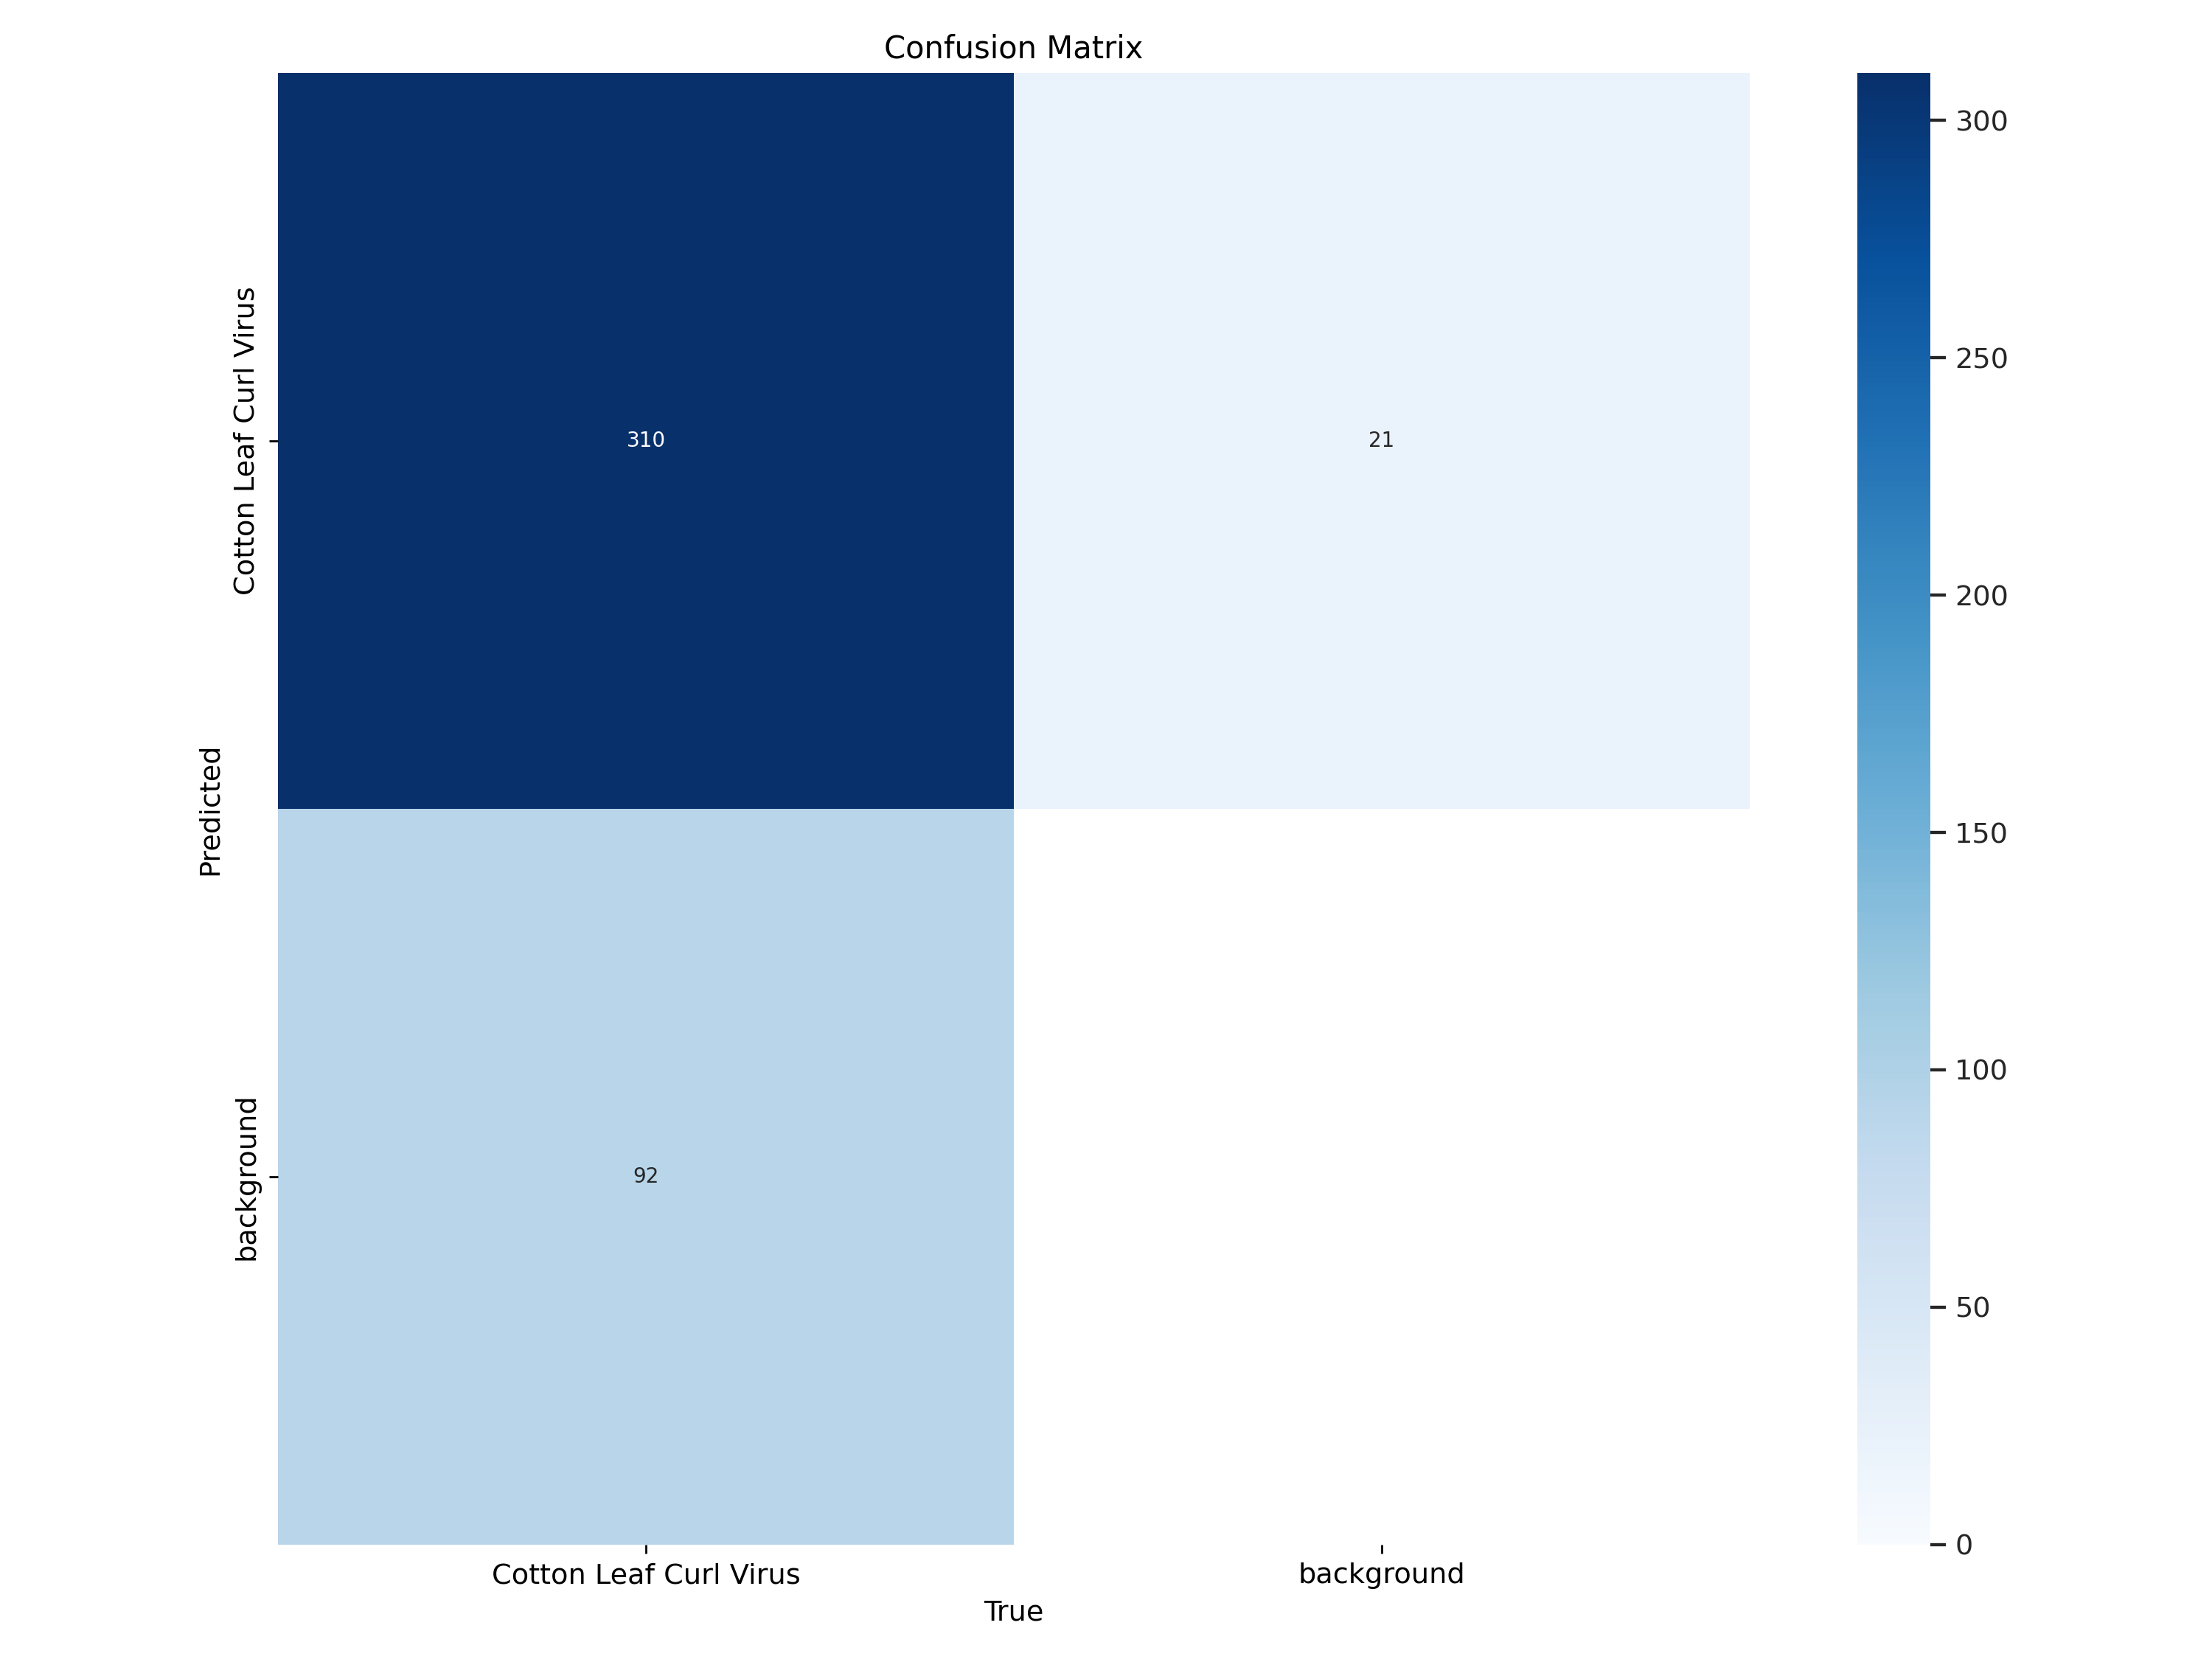

In [ ]:
Image('/content/runs/detect/train/confusion_matrix.png',width=640)

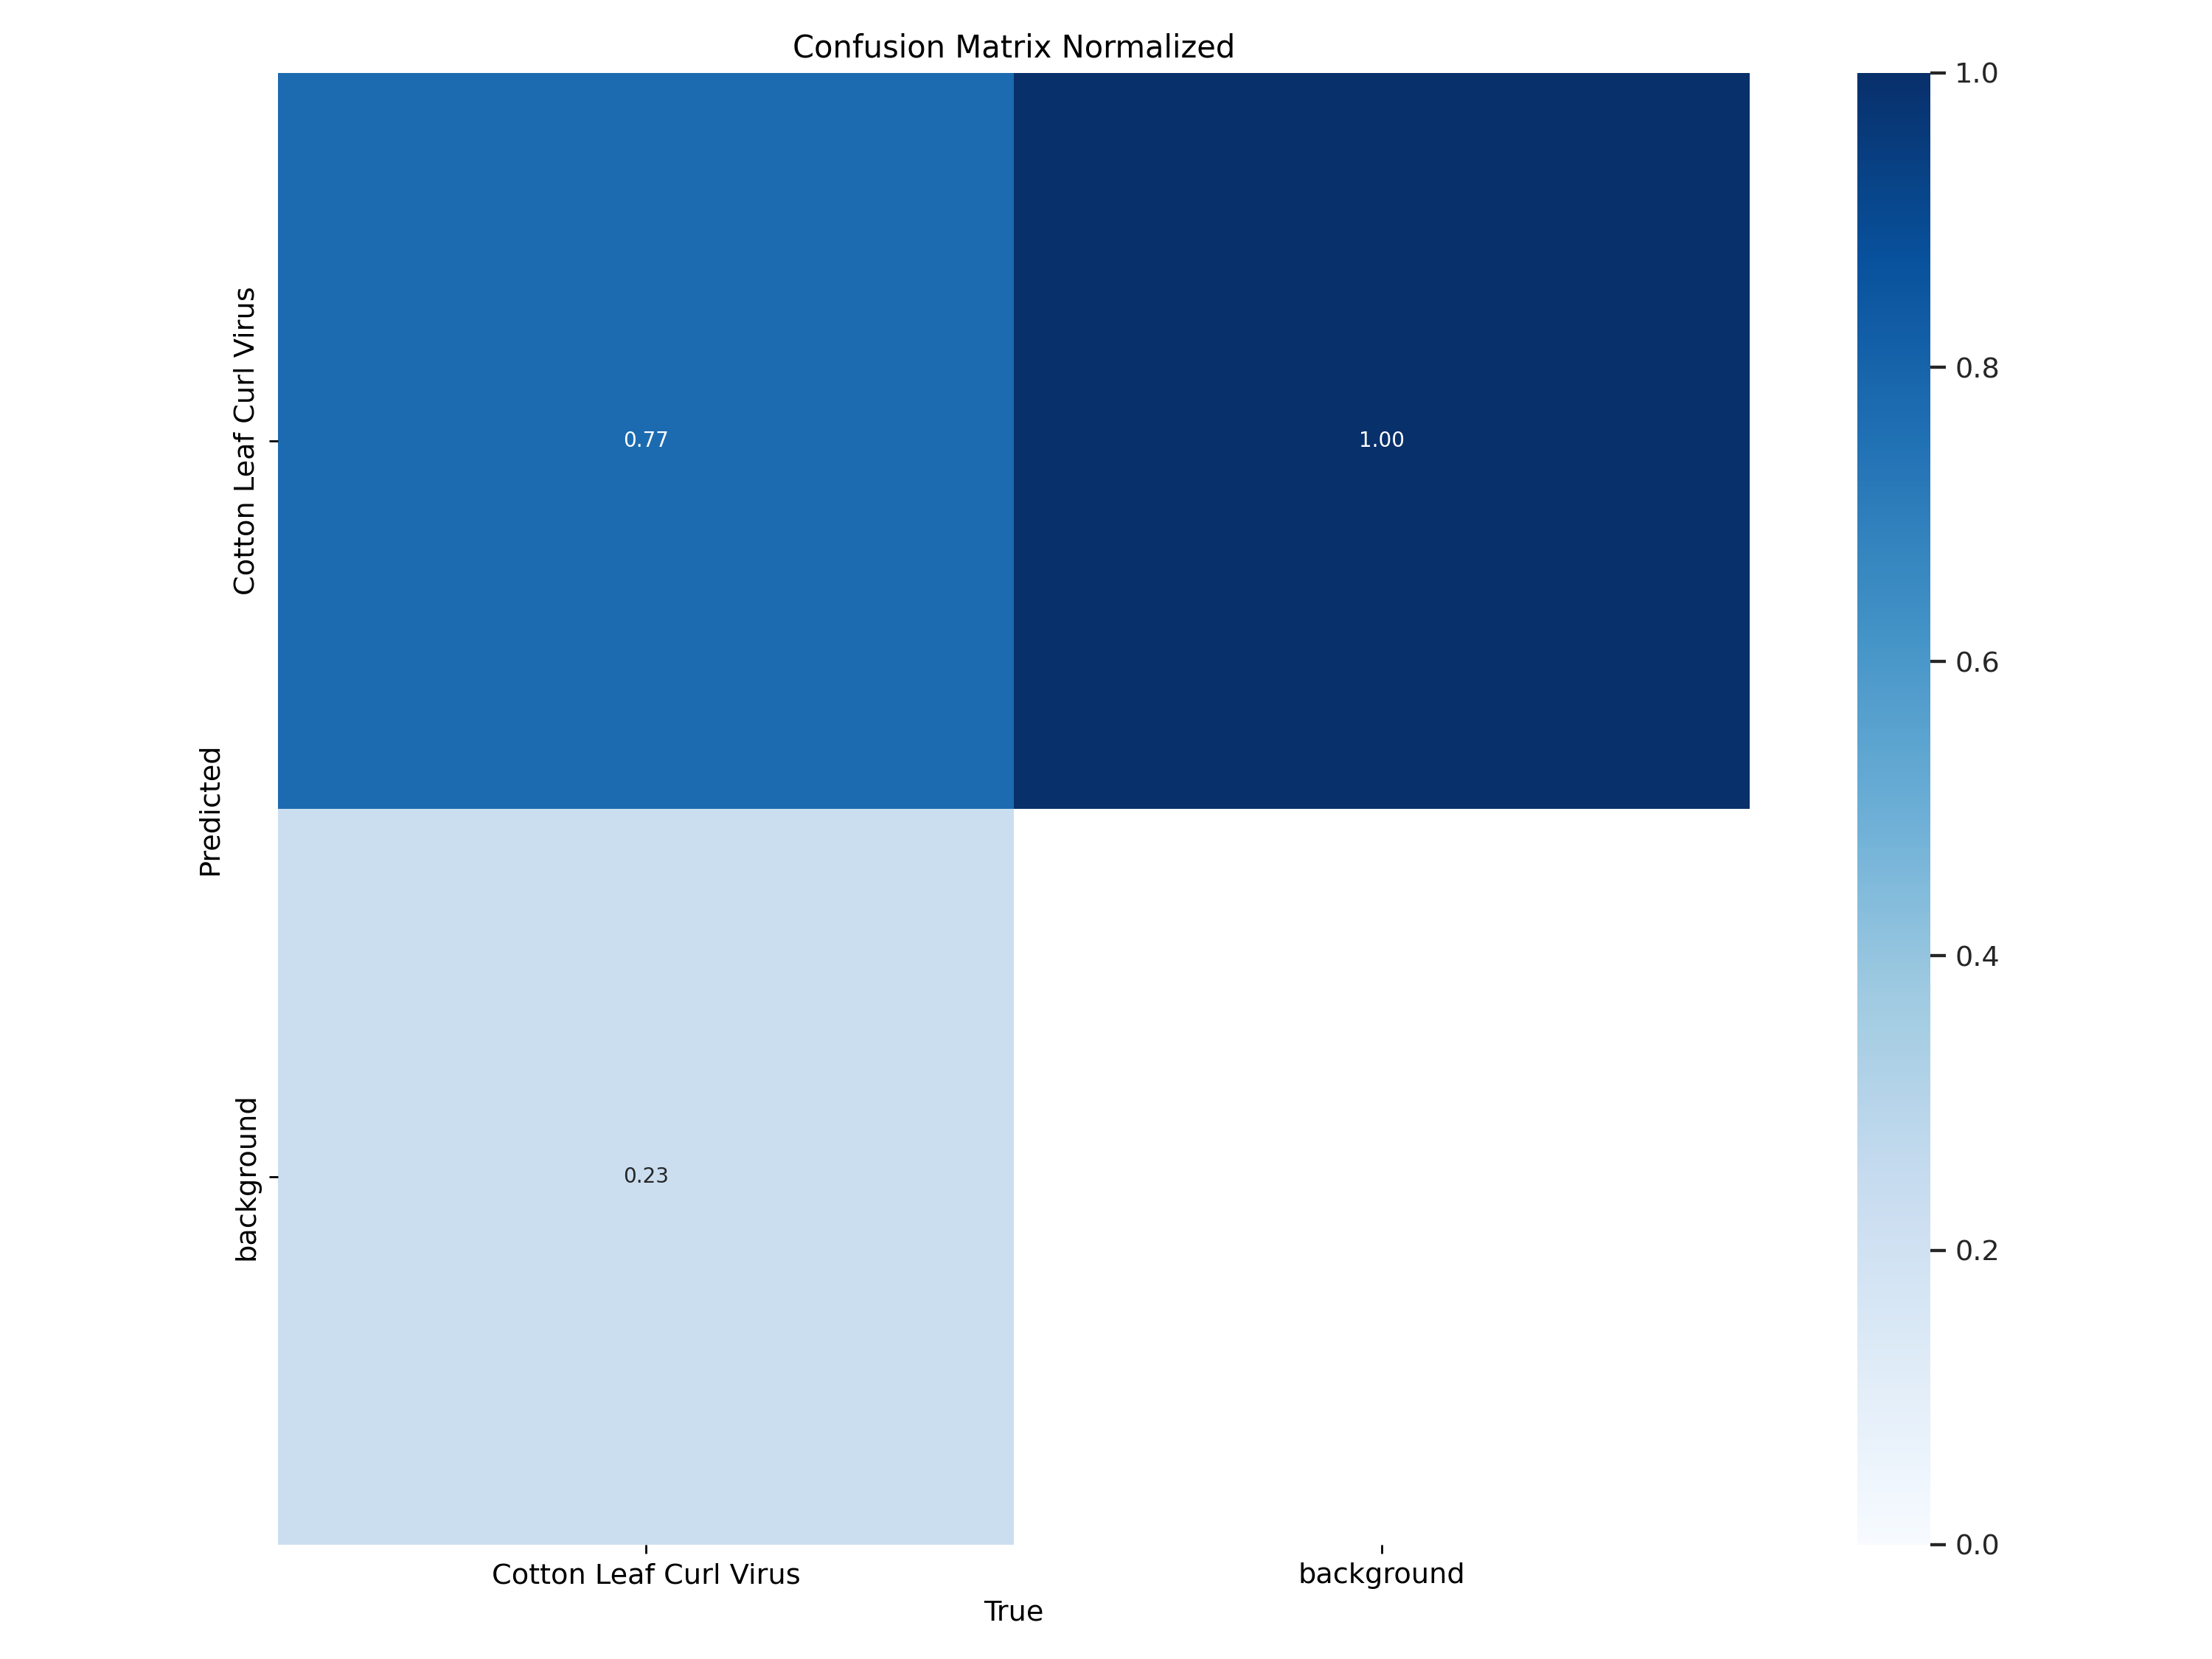

In [ ]:
Image('/content/runs/detect/train/confusion_matrix_normalized.png',width=640)

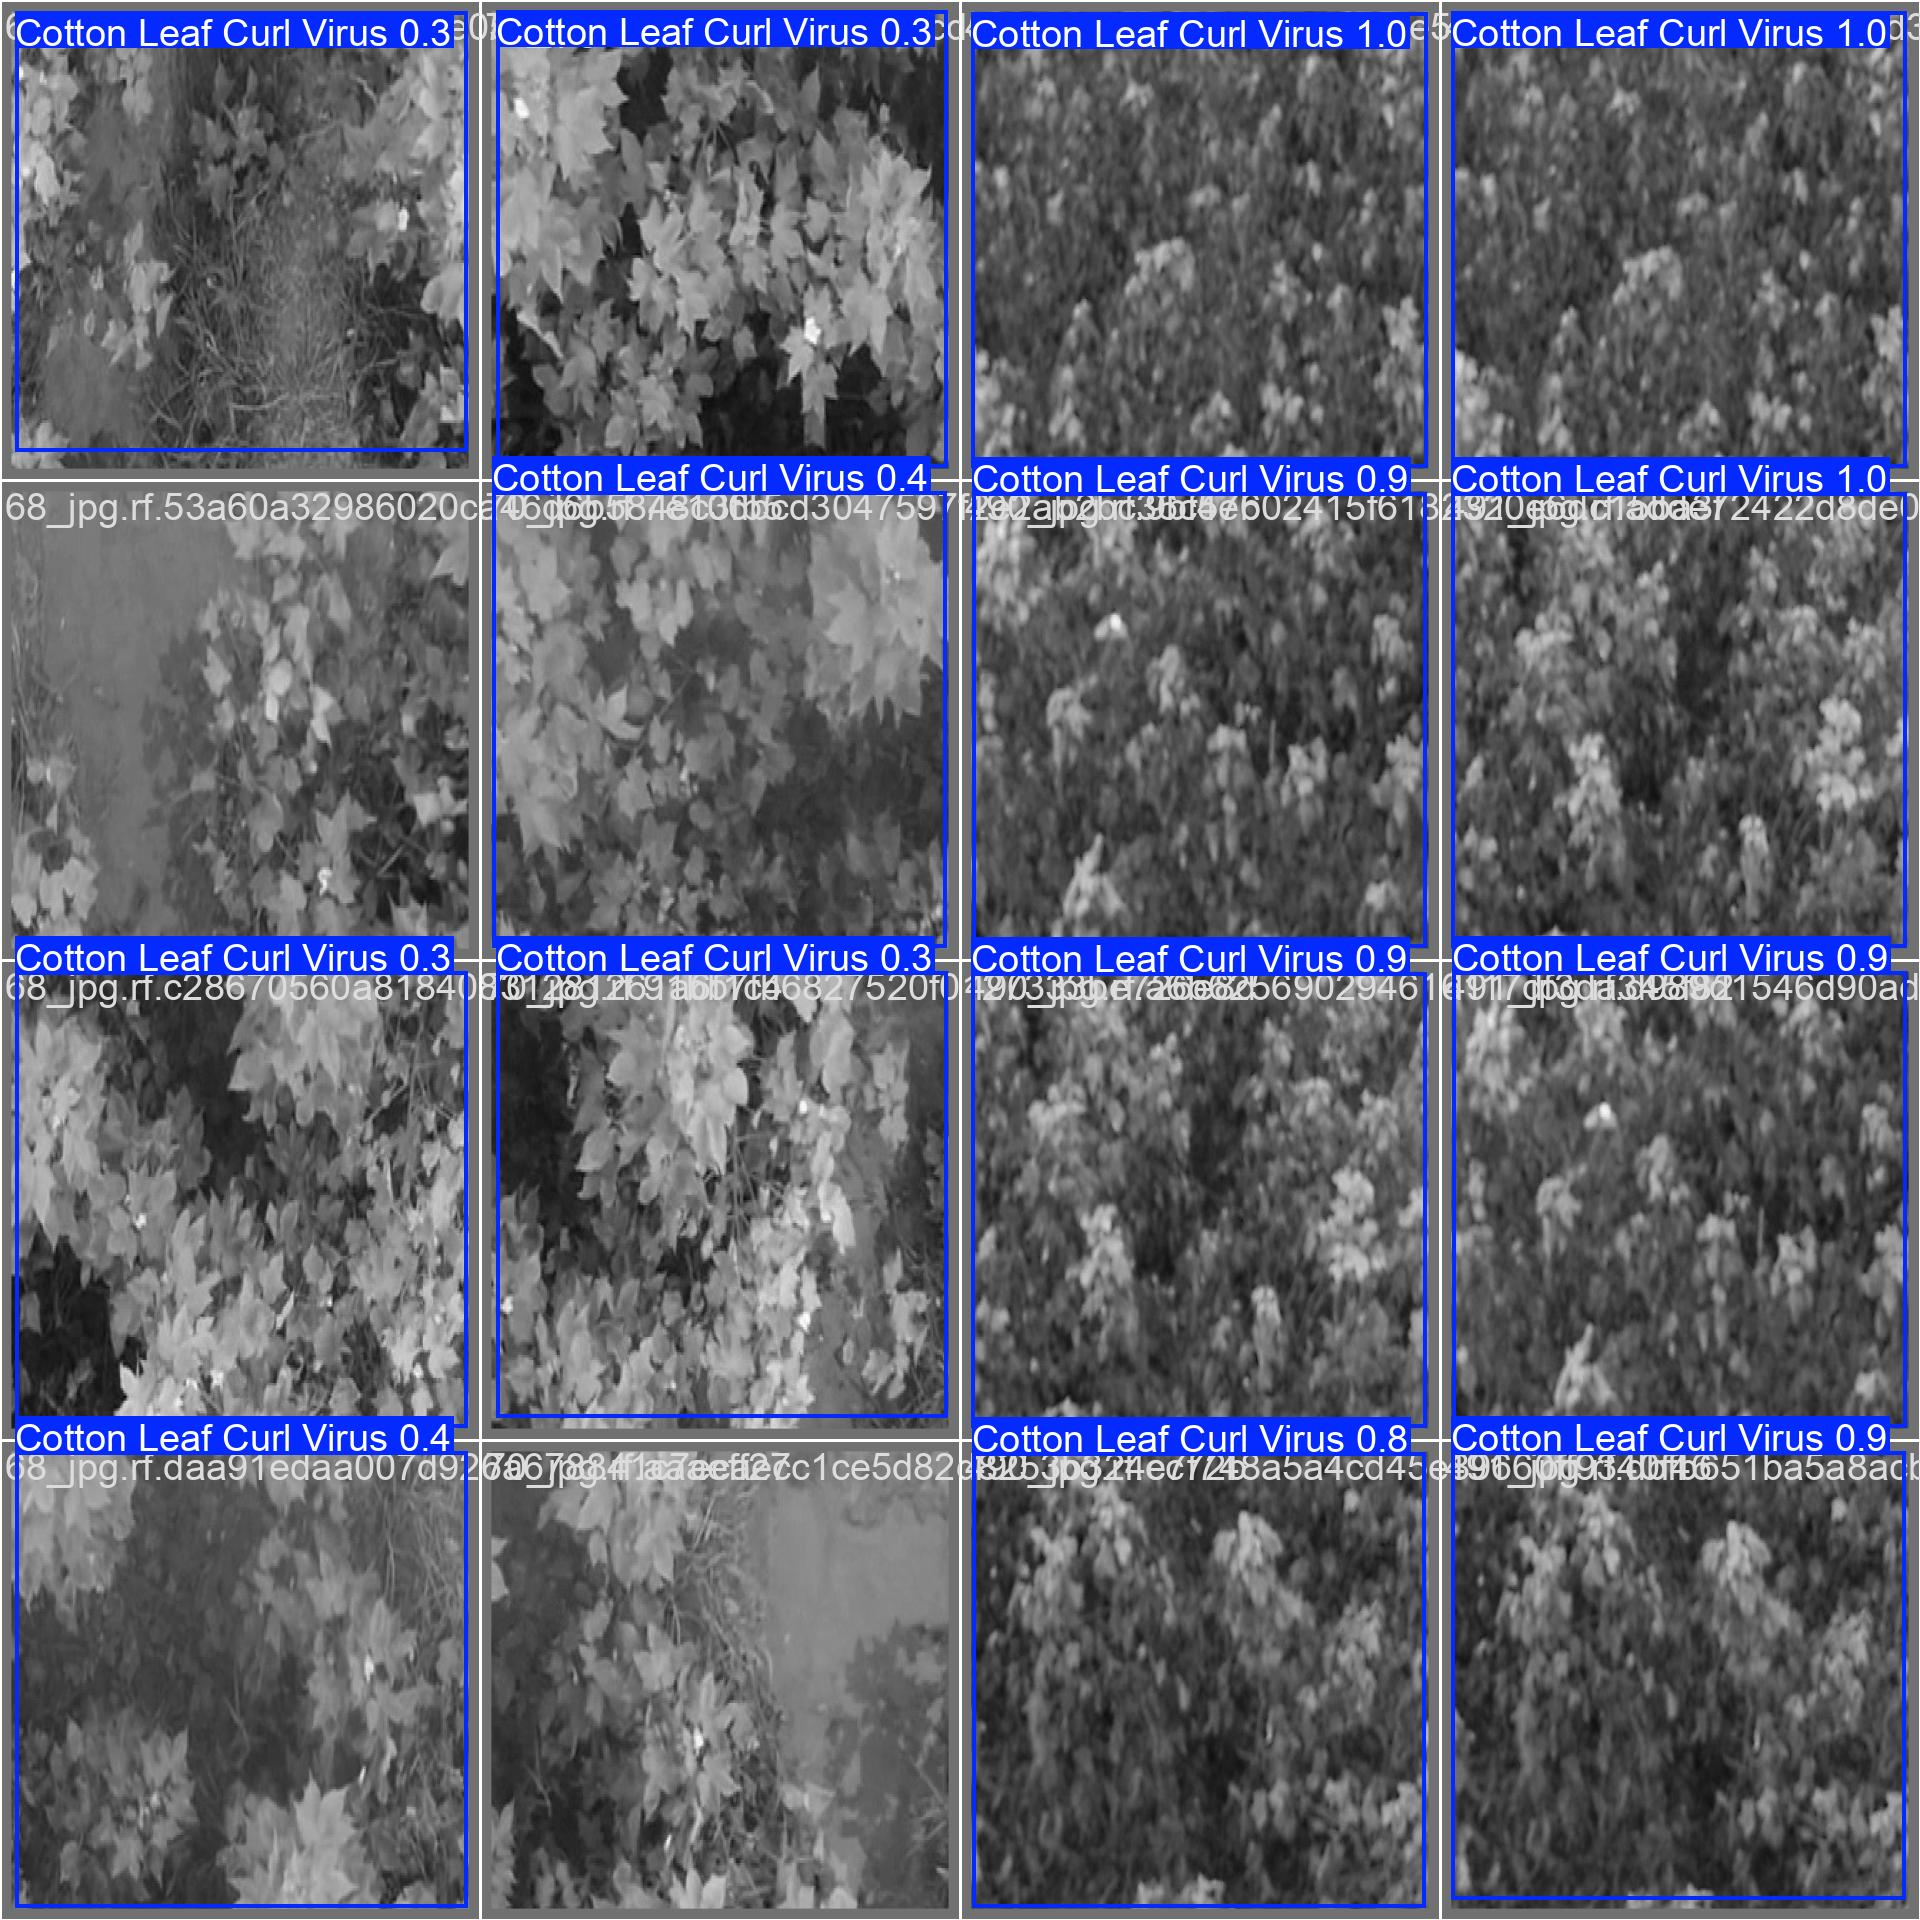

In [ ]:
Image('/content/runs/detect/train/val_batch0_pred.jpg',width=640)